# 03 - Análisis de Datos y Conveniencia (Proyecto Los 6 Octanos)

Este notebook documenta el análisis principal de los datos de precios de combustibles en Chile y la validación de la lógica utilizada en la aplicación interactiva del equipo.

## Pregunta de Análisis
> **¿Cómo varían los precios de los combustibles en las distintas regiones y comunas de Chile, cuáles son los precios promedio por distribuidor (marca), y cómo implementamos una regla lógica para recomendar la mejor opción al usuario?**

## Objetivos del Notebook
1. Cargar el dataset procesado y limpio.
2. Analizar descriptivamente los precios de los combustibles principales.
3. Evaluar los precios promedio por Región y Comuna.
4. Comparar el precio promedio por Distribuidor (Marca), alineado con las estadísticas de la aplicación.
5. Simular la **heurística de conveniencia** (penalización precio-tiempo) implementada en el recomendador del mapa.
6. Documentar las limitaciones del modelo actual y proponer la incorporación de la autonomía del vehículo (km/L) como trabajo a futuro para una versión posterior.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración estética de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Identificar rutas de datos de manera robusta
DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../../data")

archivo_limpio = DATA_DIR / "dataset_limpio.csv"
print(f"Ruta al archivo limpio: {archivo_limpio.resolve()}")


Ruta al archivo limpio: C:\Users\nicot\Documents\GitHub\sic_2026_c-p_cohort_1\proyectos\los-6-octanos\data\dataset_limpio.csv


In [2]:
# Cargar el dataset limpio
df = pd.read_csv(archivo_limpio, encoding="utf-8-sig")

# Limpiar posibles caracteres BOM en las columnas
df.columns = df.columns.str.replace("^﻿+", "", regex=True)

print(f"Dimensiones del dataset: {df.shape}")
df.head()


Dimensiones del dataset: (8580, 21)


,codigo_estacion,razon_social,distribuidor,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,...,longitud,tipo_combustible,nombre_combustible,combustible_base,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,en_mantenimiento
0,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,...,-70.303257,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,08:26:11,$/L,Asistido,0
1,co1510101,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,...,-70.313417,93,Gasolina 93,Gasolina 93,1576.0,2026-06-18,10:58:34,$/L,Asistido,0
2,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,...,-70.289095,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,09:53:12,$/L,Asistido,0
3,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,...,-70.302297,93,Gasolina 93,Gasolina 93,1568.0,2026-06-17,23:57:50,$/L,Asistido,0
4,co1510104,ESTACIONES DE SERVICIO SEGUEL Y CIA . LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,18 DE SEPTIEMBRE 2401,...,-70.290275,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,07:11:56,$/L,Asistido,0


## 1. Análisis Descriptivo General

Comenzamos evaluando la cobertura del dataset y las estadísticas de precios para los combustibles principales que maneja la aplicación.


In [3]:
# Combustibles principales a analizar
combustibles_principales = [
    "Gasolina 93", "Gasolina 95", "Gasolina 97", "Petróleo Diesel"
]
df_filtrado = df[df["nombre_combustible"].isin(combustibles_principales)]

# Estadísticas descriptivas básicas de los precios
stats_precios = df_filtrado.groupby("nombre_combustible")["precio"].describe()
stats_precios.round(1)


,count,mean,std,min,25%,50%,75%,max
nombre_combustible,,,,,,,,
Gasolina 93,1627.0,1529.7,356.3,1124.0,1492.0,1514.0,1555.0,15700.0
Gasolina 95,1628.0,1567.4,361.2,1170.0,1529.0,1557.0,1587.0,15950.0
Gasolina 97,1431.0,1627.7,642.5,1230.0,1573.0,1596.0,1617.0,16270.0
Petróleo Diesel,1666.0,1368.9,313.7,317.0,1323.0,1348.0,1383.0,13860.0


### Distribución General de Precios

Visualizamos la densidad de precios para entender los rangos y la variabilidad de cada combustible.


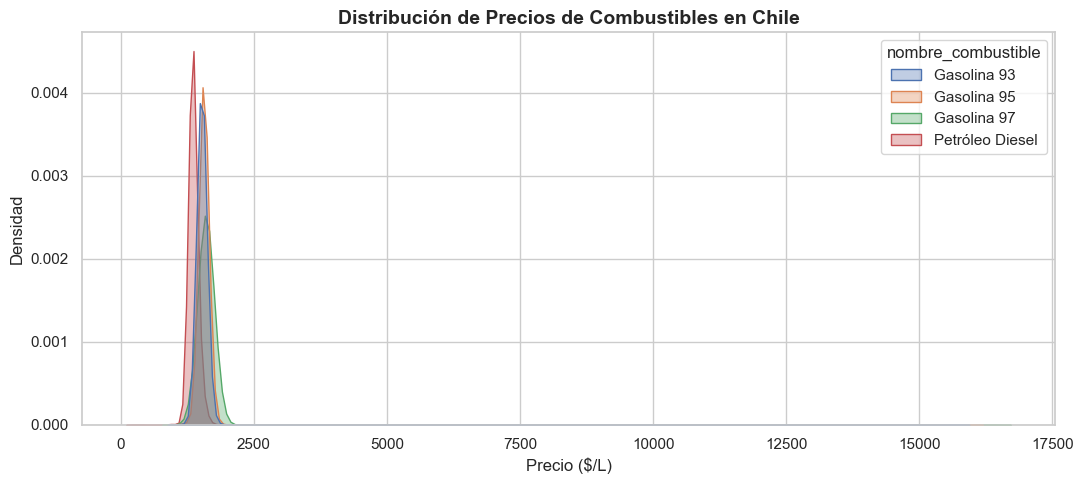

In [4]:
plt.figure(figsize=(11, 5))
sns.kdeplot(data=df_filtrado, x="precio", hue="nombre_combustible", fill=True, alpha=0.35, common_norm=False)
plt.title("Distribución de Precios de Combustibles en Chile", fontsize=14, fontweight="bold")
plt.xlabel("Precio ($/L)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Precios Promedio por Región y Comuna

Analizaremos la variación territorial del combustible. Esto nos permite responder qué zonas del país registran los valores promedio más altos y más bajos.


C:\Users\nicot\AppData\Local\Temp\ipykernel_31456\3290403594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regiones_93, x="precio", y="region", palette="RdYlGn_r")


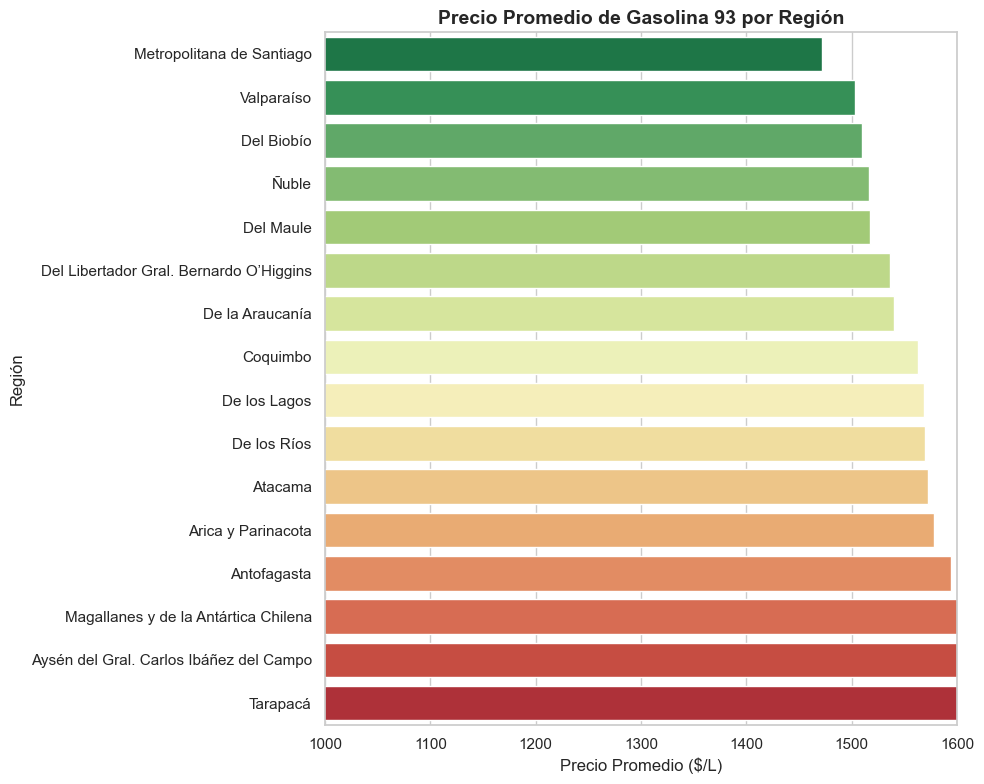

In [5]:
# Precio promedio de Gasolina 93 por Región
regiones_93 = df[df["nombre_combustible"] == "Gasolina 93"].groupby("region")["precio"].mean().reset_index()
regiones_93 = regiones_93.sort_values("precio")

plt.figure(figsize=(10, 8))
sns.barplot(data=regiones_93, x="precio", y="region", palette="RdYlGn_r")
plt.title("Precio Promedio de Gasolina 93 por Región", fontsize=14, fontweight="bold")
plt.xlabel("Precio Promedio ($/L)", fontsize=12)
plt.ylabel("Región", fontsize=12)
plt.xlim(1000, 1600)  # Zoom al rango real
plt.tight_layout()
plt.show()


In [6]:
# Mostrar las 10 comunas con promedio más barato y más caro para Gasolina 93
comunas_93 = df[df["nombre_combustible"] == "Gasolina 93"].groupby("comuna")["precio"].mean().reset_index()

print("Top 10 comunas con Gasolina 93 más barata en promedio:")
print(comunas_93.sort_values("precio").head(10).to_string(index=False))
print("\n" + "="*50 + "\n")
print("Top 10 comunas con Gasolina 93 más cara en promedio:")
print(comunas_93.sort_values("precio", ascending=False).head(10).to_string(index=False))


Top 10 comunas con Gasolina 93 más barata en promedio:
          comuna      precio
         Navidad 1348.000000
Estación Central 1414.800000
   Quinta Normal 1415.181818
       San Ramón 1424.000000
        Recoleta 1425.000000
          Calera 1430.000000
           Maipú 1436.230769
     Cerro Navia 1436.333333
           Macul 1438.888889
           Ñuñoa 1443.250000


Top 10 comunas con Gasolina 93 más cara en promedio:
        comuna      precio
       Iquique 2472.750000
     Puqueldón 1833.000000
Cabo de Hornos 1778.000000
     Primavera 1752.000000
        Tortel 1731.000000
       Chaitén 1729.000000
    Curarrehue 1725.000000
      Cochrane 1688.000000
   Chile Chico 1659.333333
        Cisnes 1658.000000


## 3. Precios Promedio por Distribuidor (Marca)

Evaluaremos las diferencias de precios promedio entre las distintas marcas o distribuidores de combustible para verificar cuáles ofrecen los valores promedio más competitivos.


In [7]:
# Estandarizar nombres de distribuidores
df["distribuidor_std"] = df["distribuidor"].str.upper().str.strip()

# Filtrar marcas principales
marcas_principales = ["COPEC", "SHELL", "PETROBRAS", "ARAMCO"]
df_marcas = df[
    (df["nombre_combustible"] == "Gasolina 93") & 
    (df["distribuidor_std"].isin(marcas_principales))
]

# Calcular el precio promedio por marca
brand_avg = df_marcas.groupby("distribuidor_std")["precio"].mean().reset_index().sort_values("precio")
brand_avg.round(1)


,distribuidor_std,precio
2,SHELL,1513.2
0,ARAMCO,1534.3
1,COPEC,1540.5


C:\Users\nicot\AppData\Local\Temp\ipykernel_31456\4022457282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_avg, x="distribuidor_std", y="precio", palette="Blues_d")


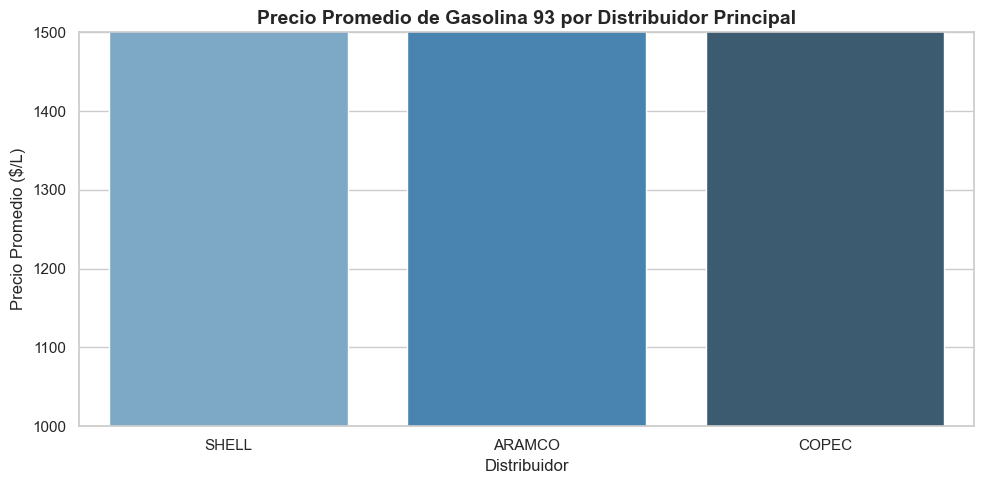

In [8]:
# Graficar precios promedio por Distribuidor
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_avg, x="distribuidor_std", y="precio", palette="Blues_d")
plt.title("Precio Promedio de Gasolina 93 por Distribuidor Principal", fontsize=14, fontweight="bold")
plt.xlabel("Distribuidor", fontsize=12)
plt.ylabel("Precio Promedio ($/L)", fontsize=12)
plt.ylim(1000, 1500)
plt.tight_layout()
plt.show()


## 4. Lógica del Recomendador: Simulación de la Heurística de Conveniencia

Dado que en esta versión no le preguntamos al usuario por la autonomía de su vehículo ni los litros a cargar, la aplicación implementa una **heurística de conveniencia basada en tiempo**. 

Esta regla balancea el precio de la estación contra el tiempo estimado de viaje (ETA) recibido desde la API de Google Maps:

$$	ext{Puntaje} = 	ext{Precio Estación} + (	ext{Tiempo de viaje en minutos} 	imes 15)$$

El valor **15** es un factor que asume una penalización implícita: un conductor está dispuesto a manejar 1 minuto extra si ahorra al menos $15 por litro de combustible. La estación con el menor puntaje es la recomendada.


In [9]:
# Simulación del Recomendador con 4 estaciones hipotéticas
estaciones_ejemplo = pd.DataFrame({
    "Estación": ["Estación A (Esquina)", "Estación B (Lejana)", "Estación C (Recomendada)", "Estación D (Extrema)"],
    "Precio ($/L)": [1420, 1340, 1360, 1310],
    "Tiempo de Viaje (min)": [1, 10, 3, 15]
})

# Calcular el puntaje heurístico
estaciones_ejemplo["Penalización Tiempo ($)"] = estaciones_ejemplo["Tiempo de Viaje (min)"] * 15
estaciones_ejemplo["Puntaje Conveniencia"] = estaciones_ejemplo["Precio ($/L)"] + estaciones_ejemplo["Penalización Tiempo ($)"]

# Ordenar de mejor a peor conveniencia
estaciones_ejemplo = estaciones_ejemplo.sort_values("Puntaje Conveniencia")
estaciones_ejemplo


,Estación,Precio ($/L),Tiempo de Viaje (min),Penalización Tiempo ($),Puntaje Conveniencia
2,Estación C (Recomendada),1360,3,45,1405
0,Estación A (Esquina),1420,1,15,1435
1,Estación B (Lejana),1340,10,150,1490
3,Estación D (Extrema),1310,15,225,1535


## 5. Limitaciones del Modelo Actual y Propuesta de Trabajo Futuro (Rendimiento del Auto)

El modelo de recomendación basado en la penalización de $15/minuto es una estimación general. 

Para una versión posterior (Versión 4), el equipo tiene como objetivo transicionar a un **modelo de Ahorro Neto Real**, el cual requerirá que el usuario ingrese:
1. **Litros a cargar ($L_{carga}$)**
2. **Rendimiento o Autonomía del vehículo ($R_{kml}$ en km/L)**

### Formulación para la versión futura:
* **Consumo del desvío (Litros):**
  $$L_{desvio} = rac{	ext{Distancia real de viaje} 	imes 2}{	ext{Rendimiento del auto (km/L)}}$$

* **Costo de combustible por el desvío ($):**
  $$C_{desvio} = L_{desvio} 	imes P_{estacion}$$

* **Ahorro Bruto ($) vs el promedio comunal:**
  $$A_{bruto} = (P_{promedio} - P_{estacion}) 	imes L_{carga}$$

* **Ahorro Neto Real ($):**
  $$A_{neto} = A_{bruto} - C_{desvio}$$

Solo se recomendaría desviar al usuario si el **Ahorro Neto Real es mayor a cero** ($A_{neto} > 0$).


In [10]:
# Simulación conceptual de cómo funcionará el cálculo de ahorro en la V4
def simular_ahorro_v4(precio_estacion, precio_promedio_comuna, distancia_km, rendimiento_kml, litros_carga):
    distancia_total = distancia_km * 2 # Ida y vuelta
    litros_viaje = distancia_total / rendimiento_kml
    costo_viaje = litros_viaje * precio_estacion
    ahorro_bruto = (precio_promedio_comuna - precio_estacion) * litros_carga
    ahorro_neto = ahorro_bruto - costo_viaje
    return int(ahorro_neto)

# Ejemplo: Cargar 40L, auto rinde 12 km/L.
# Estación cercana (1 km desvío) vs lejana (7 km desvío), ambas con descuento de $50/L respecto al promedio
ahorro_cercano = simular_ahorro_v4(1350, 1400, 1, 12, 40)
ahorro_lejano = simular_ahorro_v4(1350, 1400, 7, 12, 40)

print(f"Ahorro Neto Real si la estación barata está a 1 km: ${ahorro_cercano} CLP (CONVIENE)")
print(f"Ahorro Neto Real si la estación barata está a 7 km: ${ahorro_lejano} CLP (NO CONVIENE, pérdida)")


Ahorro Neto Real si la estación barata está a 1 km: $1775 CLP (CONVIENE)
Ahorro Neto Real si la estación barata está a 7 km: $425 CLP (NO CONVIENE, pérdida)


## Conclusiones del Análisis

1. **Variación Territorial:** Existe una marcada variación de precios de combustibles a nivel regional y comunal en Chile, lo que justifica la existencia de un explorador de precios georreferenciado.
2. **Distribuidor:** Los precios promedio de las marcas varían sutilmente, existiendo ligeras diferencias de precios promedios a nivel general, pero las variaciones locales por ubicación geográfica resultan más significativas para el usuario.
3. **Mapeo y Recomendación:** La app implementa exitosamente una heurística que penaliza el tiempo de viaje ($15 por minuto) para evitar desvíos irracionales a estaciones baratas pero demasiado lejanas.
4. **Siguiente Iteración (Trabajo Futuro):** Para una versión posterior de la app se integrarán las variables de **autonomía de vehículo (km/L)** y **volumen de carga (L)** en sliders interactivos, permitiendo calcular el ahorro de bolsillo de manera matemática y personalizada.
